#📌 Extracción

In [1]:
import pandas as pd

# URL del archivo JSON en GitHub raw
api_url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json'

# Cargar los datos directamente desde la API a un DataFrame de Pandas
try:
    df_telecom = pd.read_json(api_url)
    print("Datos cargados exitosamente:")
    print(df_telecom.head())
    print(f"Dimensiones del DataFrame: {df_telecom.shape}")
except Exception as e:
    print(f"Error al cargar los datos: {e}")

Datos cargados exitosamente:
   customerID Churn                                           customer  \
0  0002-ORFBO    No  {'gender': 'Female', 'SeniorCitizen': 0, 'Part...   
1  0003-MKNFE    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
2  0004-TLHLJ   Yes  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
3  0011-IGKFF   Yes  {'gender': 'Male', 'SeniorCitizen': 1, 'Partne...   
4  0013-EXCHZ   Yes  {'gender': 'Female', 'SeniorCitizen': 1, 'Part...   

                                             phone  \
0   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
1  {'PhoneService': 'Yes', 'MultipleLines': 'Yes'}   
2   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
3   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
4   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   

                                            internet  \
0  {'InternetService': 'DSL', 'OnlineSecurity': '...   
1  {'InternetService': 'DSL', 'OnlineSecurity': '...   
2  {'InternetService': 'Fiber opt

In [2]:
# Desanidar la columna 'customer'
df_customer = pd.json_normalize(df_telecom['customer'])

# Desanidar la columna 'phone'
df_phone = pd.json_normalize(df_telecom['phone'])

# Desanidar la columna 'internet'
df_internet = pd.json_normalize(df_telecom['internet'])

# Desanidar la columna 'account'
df_account = pd.json_normalize(df_telecom['account'])

# Unir los DataFrames desanidados al DataFrame original
df_telecom = pd.concat([
    df_telecom.drop(columns=['customer', 'phone', 'internet', 'account']),
    df_customer,
    df_phone,
    df_internet,
    df_account
], axis=1)

print("Columnas desanidadas exitosamente. Primeras 5 filas del DataFrame final:")
display(df_telecom.head())
print(f"Dimensiones del DataFrame final: {df_telecom.shape}")

Columnas desanidadas exitosamente. Primeras 5 filas del DataFrame final:


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


Dimensiones del DataFrame final: (7267, 21)


#🔧 Transformación

In [6]:
import numpy as np
import pandas as pd

print("\n--- Información general del DataFrame antes de la limpieza ---")
df_telecom.info()

print("\n--- Verificación de valores ausentes antes de la limpieza ---")
missing_values = df_telecom.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
if not missing_values.empty:
    print(missing_values)
else:
    print("No hay valores ausentes en el DataFrame.")

print("\n--- Verificación de filas duplicadas ---")
duplicated_rows = df_telecom.duplicated().sum()
if duplicated_rows > 0:
    print(f"Se encontraron {duplicated_rows} filas duplicadas.")
else:
    print("No hay filas duplicadas en el DataFrame.")

print("\n--- Inspección de valores únicos en columnas categóricas (antes de la limpieza) ---")
for column in df_telecom.select_dtypes(include='object').columns:
    if df_telecom[column].nunique() < 20: # Limitar para no imprimir demasiados valores únicos
        print(f"Columna '{column}': {df_telecom[column].unique()}")


# --- Aplicar transformaciones ---

# 1. Limpiar 'Charges.Total': reemplazar espacios por NaN y convertir a numérico
# Primero, inspeccionemos los valores únicos para confirmar la presencia de espacios
print("\nValores únicos en 'Charges.Total' antes de la limpieza:")
print(df_telecom['Charges.Total'].value_counts(dropna=False).head())

df_telecom['Charges.Total'] = df_telecom['Charges.Total'].replace(' ', np.nan) # Usar np.nan
df_telecom['Charges.Total'] = pd.to_numeric(df_telecom['Charges.Total'])
print("\n'Charges.Total' convertido a tipo numérico.")

# 2. Manejar valores vacíos en 'Churn': reemplazar '' con NaN
print("\nValores únicos en 'Churn' antes de la limpieza:")
print(df_telecom['Churn'].value_counts(dropna=False))

df_telecom['Churn'] = df_telecom['Churn'].replace('', np.nan)
print("\nValores vacíos en 'Churn' reemplazados por NaN.")

# 3. Crear la columna 'Cuentas_Diarias'
df_telecom['Cuentas_Diarias'] = df_telecom['Charges.Monthly'] / 30
print("\nColumna 'Cuentas_Diarias' creada exitosamente.")

# 4. Estandarizar valores binarios (Sí/No a 1/0, Male/Female a 1/0)
print("\n--- Estandarizando valores binarios (Yes/No, Male/Female) ---")
binary_map = {'Yes': 1, 'No': 0}
gender_map = {'Male': 1, 'Female': 0}

# Columnas con 'Yes'/'No'
for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
    df_telecom[col] = df_telecom[col].map(binary_map)
    print(f"Columna '{col}' estandarizada a binario.")

# Columna 'Churn' (incluye NaN, mapear cuidadosamente)
df_telecom['Churn'] = df_telecom['Churn'].map(binary_map)
print("Columna 'Churn' estandarizada a binario.")

# Columna 'gender'
df_telecom['gender'] = df_telecom['gender'].map(gender_map)
print("Columna 'gender' estandarizada a binario.")

# Mostrar cambios para estas columnas
print("\nPrimeras 5 filas del DataFrame después de estandarización binaria:")
display(df_telecom[['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn', 'gender']].head())


# --- Re-verificar después de la limpieza y transformación ---
print("\n--- Información general del DataFrame después de la limpieza y transformación ---")
df_telecom.info()

print("\n--- Verificación de valores ausentes después de la limpieza y transformación ---")
missing_values_after_cleaning = df_telecom.isnull().sum()
missing_values_after_cleaning = missing_values_after_cleaning[missing_values_after_cleaning > 0].sort_values(ascending=False)
if not missing_values_after_cleaning.empty:
    print(missing_values_after_cleaning)
else:
    print("No hay valores ausentes en el DataFrame después de la limpieza y transformación.")

print("\n--- Inspección de valores únicos en columnas categóricas (después de la limpieza y transformación) ---")
for column in df_telecom.select_dtypes(include='object').columns:
    if df_telecom[column].nunique() < 20: # Limitar para no imprimir demasiados valores únicos
        print(f"Columna '{column}': {df_telecom[column].unique()}")


--- Información general del DataFrame antes de la limpieza ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 no

,Partner,Dependents,PhoneService,PaperlessBilling,Churn,gender
0,1,1,1,1,0.0,0
1,0,0,1,0,0.0,1
2,0,0,1,1,1.0,1
3,1,0,1,1,1.0,1
4,1,0,1,1,1.0,0



--- Información general del DataFrame después de la limpieza y transformación ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7043 non-null   float64
 2   gender            7267 non-null   int64  
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   int64  
 5   Dependents        7267 non-null   int64  
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   int64  
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  Stream

#📊 Carga y análisis

In [7]:
print("\n--- Análisis Descriptivo del DataFrame (Columnas Numéricas) ---")
display(df_telecom.describe().T)

print("\n--- Conteo de valores para las columnas categóricas después de la limpieza y transformación ---")
for column in df_telecom.select_dtypes(include='object').columns:
    print(f"\nColumna '{column}':")
    print(df_telecom[column].value_counts(dropna=False))


--- Análisis Descriptivo del DataFrame (Columnas Numéricas) ---


,count,mean,std,min,25%,50%,75%,max
Churn,7043.0,0.265370,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
gender,7267.0,0.505711,0.500002,0.000000,0.000000,1.000000,1.000000,1.000000
SeniorCitizen,7267.0,0.162653,0.369074,0.000000,0.000000,0.000000,0.000000,1.000000
Partner,7267.0,0.484106,0.499782,0.000000,0.000000,0.000000,1.000000,1.000000
Dependents,7267.0,0.300124,0.458343,0.000000,0.000000,0.000000,1.000000,1.000000
tenure,7267.0,32.346498,24.571773,0.000000,9.000000,29.000000,55.000000,72.000000
PhoneService,7267.0,0.902711,0.296371,0.000000,1.000000,1.000000,1.000000,1.000000
PaperlessBilling,7267.0,0.593230,0.491265,0.000000,0.000000,1.000000,1.000000,1.000000
Charges.Monthly,7267.0,64.720098,30.129572,18.250000,35.425000,70.300000,89.875000,118.750000
Charges.Total,7256.0,2280.634213,2268.632997,18.800000,400.225000,1391.000000,3785.300000,8684.800000



--- Conteo de valores para las columnas categóricas después de la limpieza y transformación ---

Columna 'customerID':
customerID
9995-HOTOH    1
0002-ORFBO    1
0003-MKNFE    1
9970-QBCDA    1
9968-FFVVH    1
             ..
0014-BMAQU    1
0013-SMEOE    1
0013-MHZWF    1
0013-EXCHZ    1
0011-IGKFF    1
Name: count, Length: 7267, dtype: int64

Columna 'MultipleLines':
MultipleLines
No                  3495
Yes                 3065
No phone service     707
Name: count, dtype: int64

Columna 'InternetService':
InternetService
Fiber optic    3198
DSL            2488
No             1581
Name: count, dtype: int64

Columna 'OnlineSecurity':
OnlineSecurity
No                     3608
Yes                    2078
No internet service    1581
Name: count, dtype: int64

Columna 'OnlineBackup':
OnlineBackup
No                     3182
Yes                    2504
No internet service    1581
Name: count, dtype: int64

Columna 'DeviceProtection':
DeviceProtection
No                     3195
Yes     


--- Distribución de la variable 'Churn' ---
Churn
0.0    5174
1.0    1869
NaN     224
Name: count, dtype: int64

--- Porcentaje de la variable 'Churn' ---
Churn
0.0    71.198569
1.0    25.719004
NaN     3.082427
Name: proportion, dtype: float64


/tmp/ipykernel_442/2003263653.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Churn Status', y='Count', data=churn_data, palette='viridis')


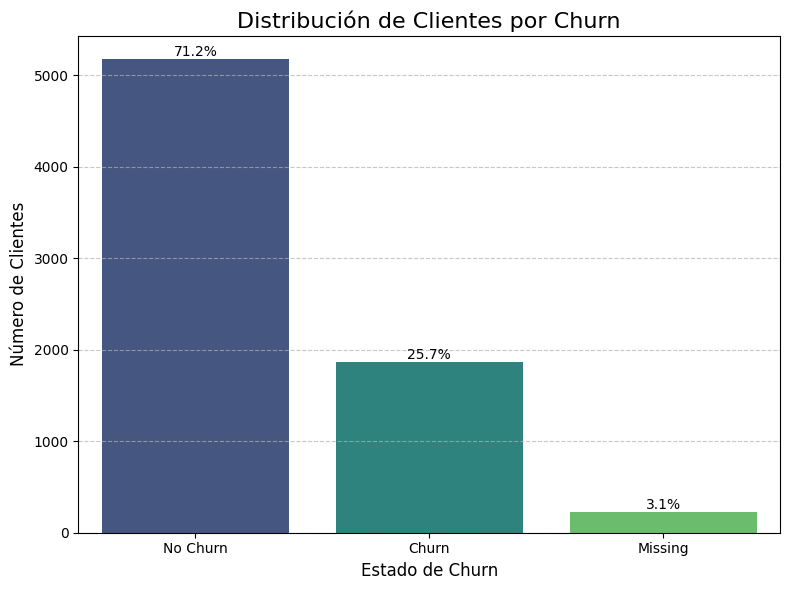

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contar la distribución de 'Churn'
churn_counts = df_telecom['Churn'].value_counts(dropna=False)
churn_percentages = df_telecom['Churn'].value_counts(normalize=True, dropna=False) * 100

print("\n--- Distribución de la variable 'Churn' ---")
print(churn_counts)
print("\n--- Porcentaje de la variable 'Churn' ---")
print(churn_percentages)

# Preparar los datos para la visualización
churn_data = pd.DataFrame({
    'Churn Status': churn_counts.index.map({0.0: 'No Churn', 1.0: 'Churn', np.nan: 'Missing'}),
    'Count': churn_counts.values,
    'Percentage': churn_percentages.values
})

plt.figure(figsize=(8, 6))
sns.barplot(x='Churn Status', y='Count', data=churn_data, palette='viridis')
plt.title('Distribución de Clientes por Churn', fontsize=16)
plt.xlabel('Estado de Churn', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Añadir porcentajes en el gráfico
for index, row in churn_data.iterrows():
    plt.text(index, row.Count, f'{row.Percentage:.1f}%', color='black', ha="center", va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

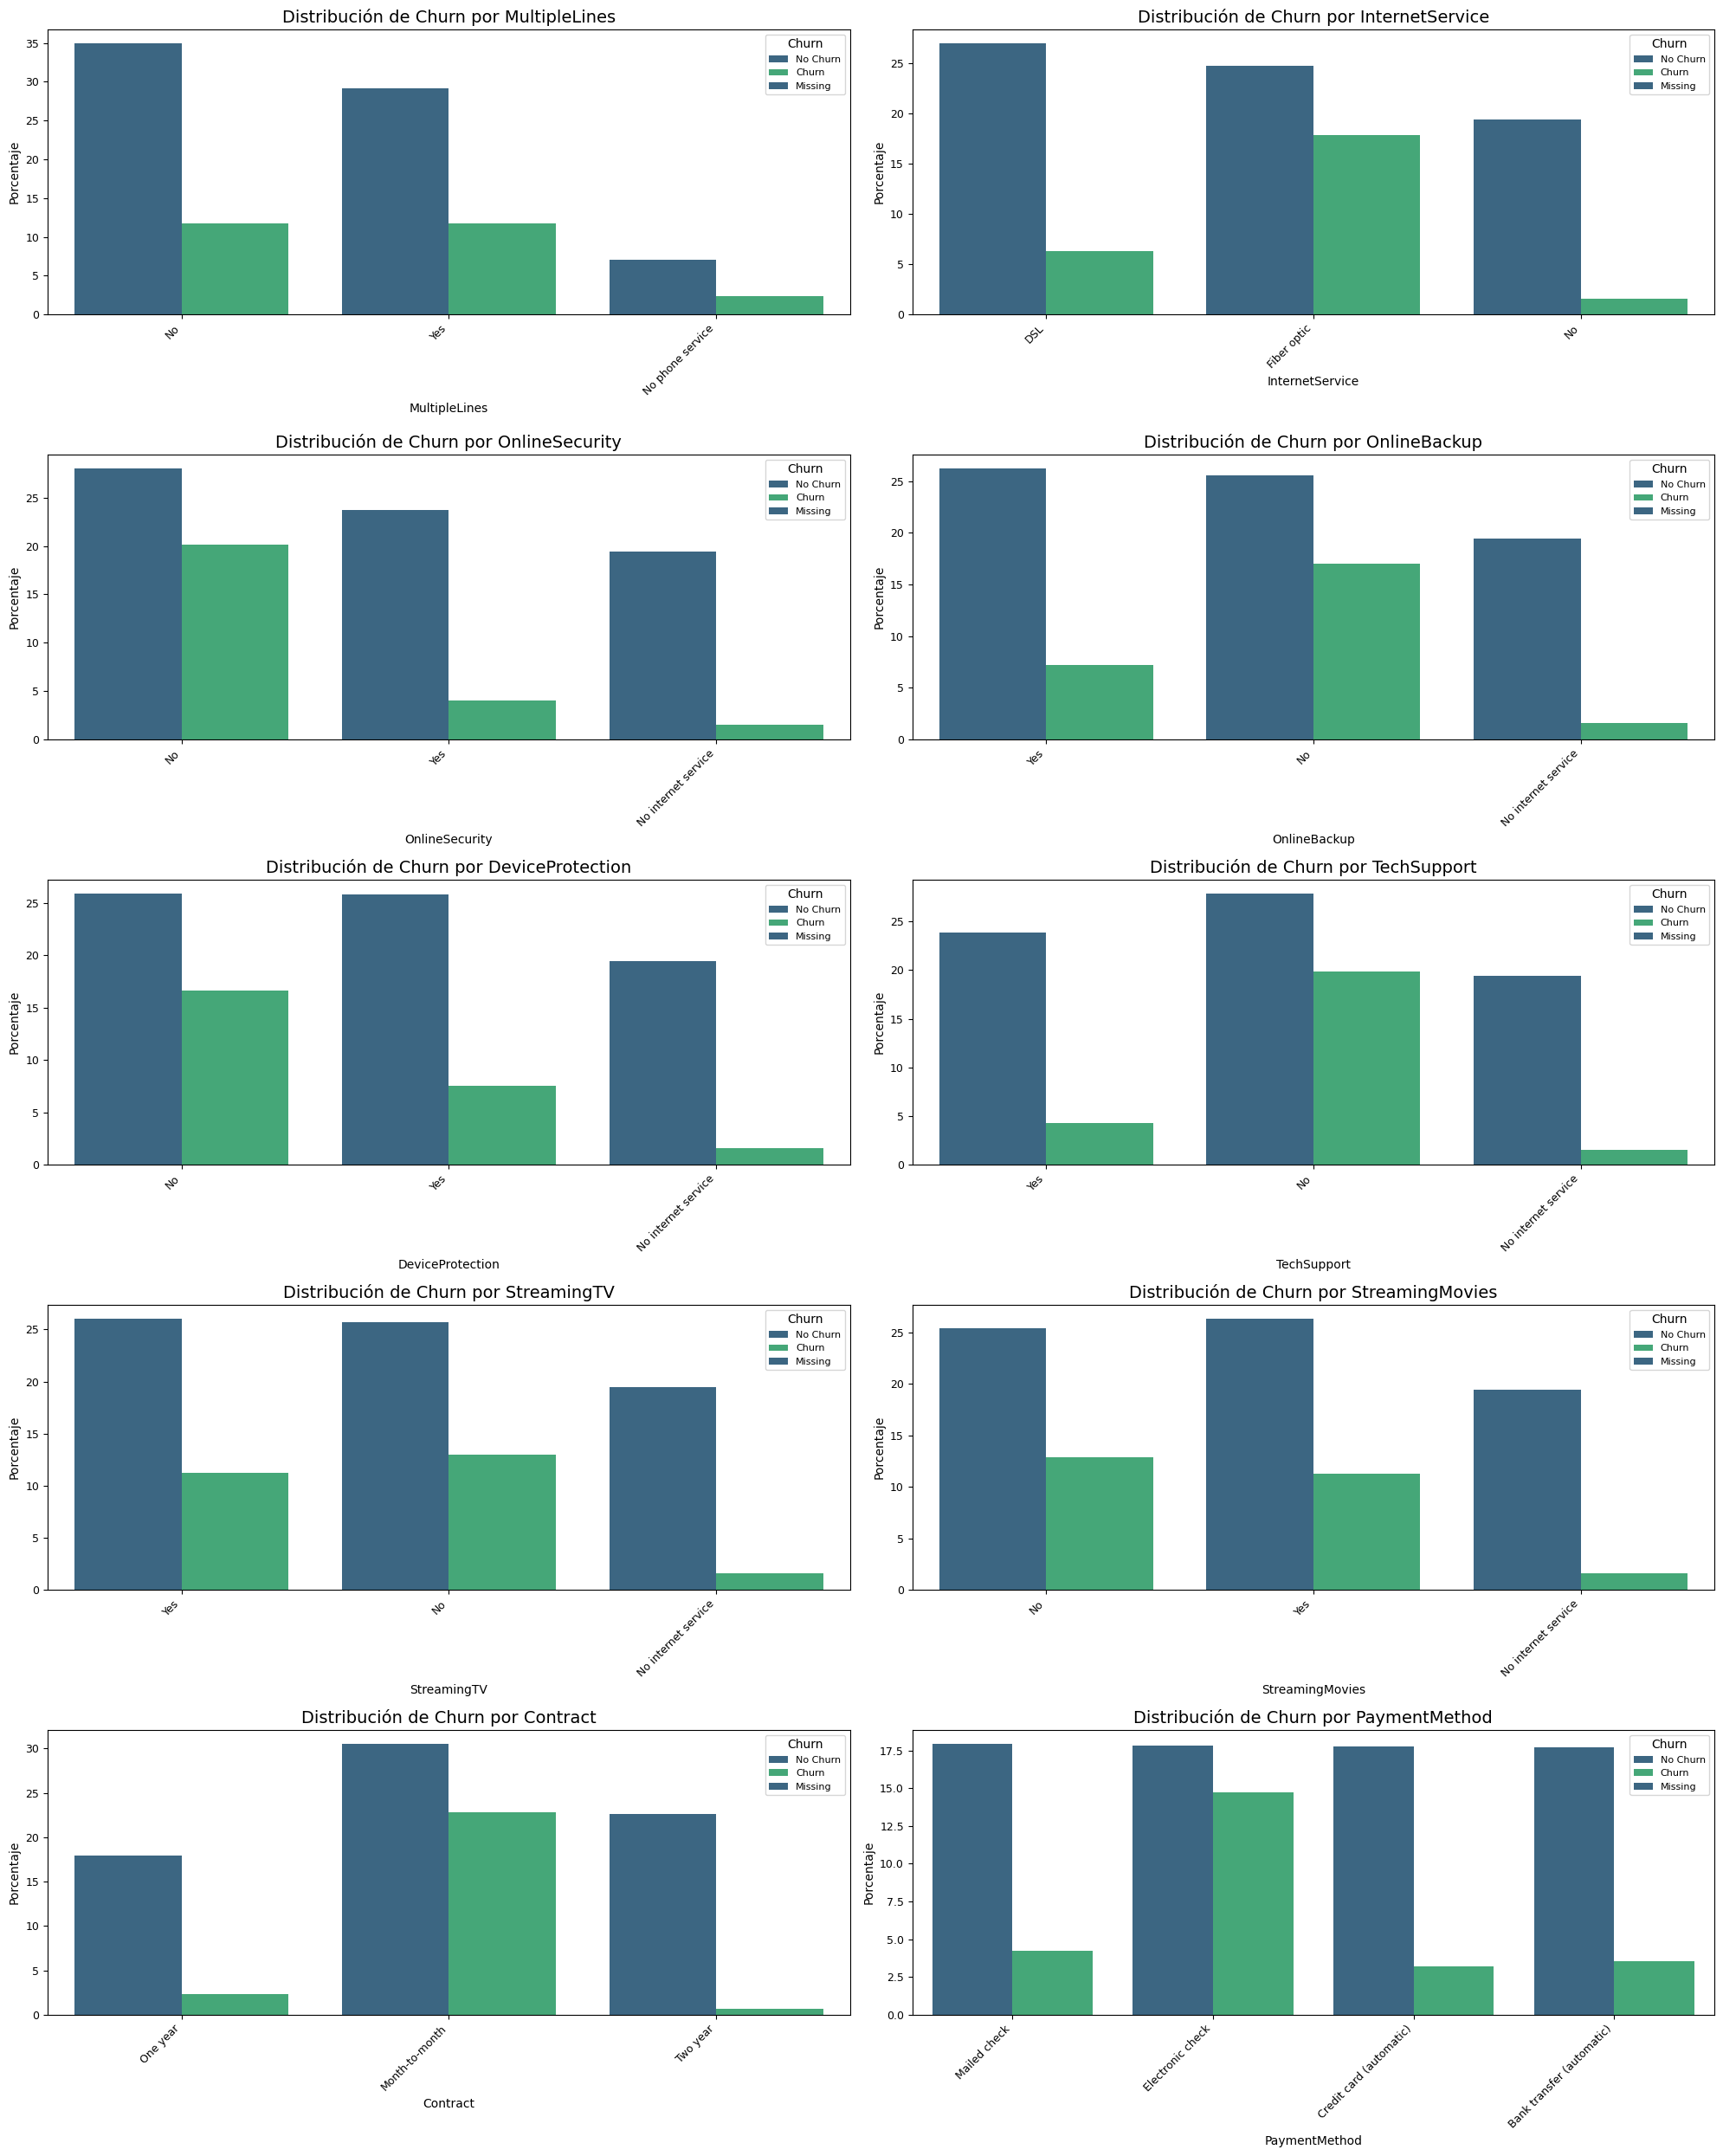

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

plt.figure(figsize=(20, 25))
for i, col in enumerate(categorical_cols):
    plt.subplot(5, 2, i + 1)
    sns.countplot(data=df_telecom, x=col, hue='Churn', palette='viridis', stat='percent')
    plt.title(f'Distribución de Churn por {col}', fontsize=14)
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Porcentaje', fontsize=10)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(fontsize=9)
    plt.legend(title='Churn', labels=['No Churn', 'Churn', 'Missing'], fontsize=8)

plt.tight_layout()
plt.show()

/tmp/ipykernel_442/1849400465.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_telecom, x='Churn', y=col, palette='magma')
/tmp/ipykernel_442/1849400465.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_telecom, x='Churn', y=col, palette='magma')
/tmp/ipykernel_442/1849400465.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_telecom, x='Churn', y=col, palette='magma')
/tmp/ipykernel_442/1849400465.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. 

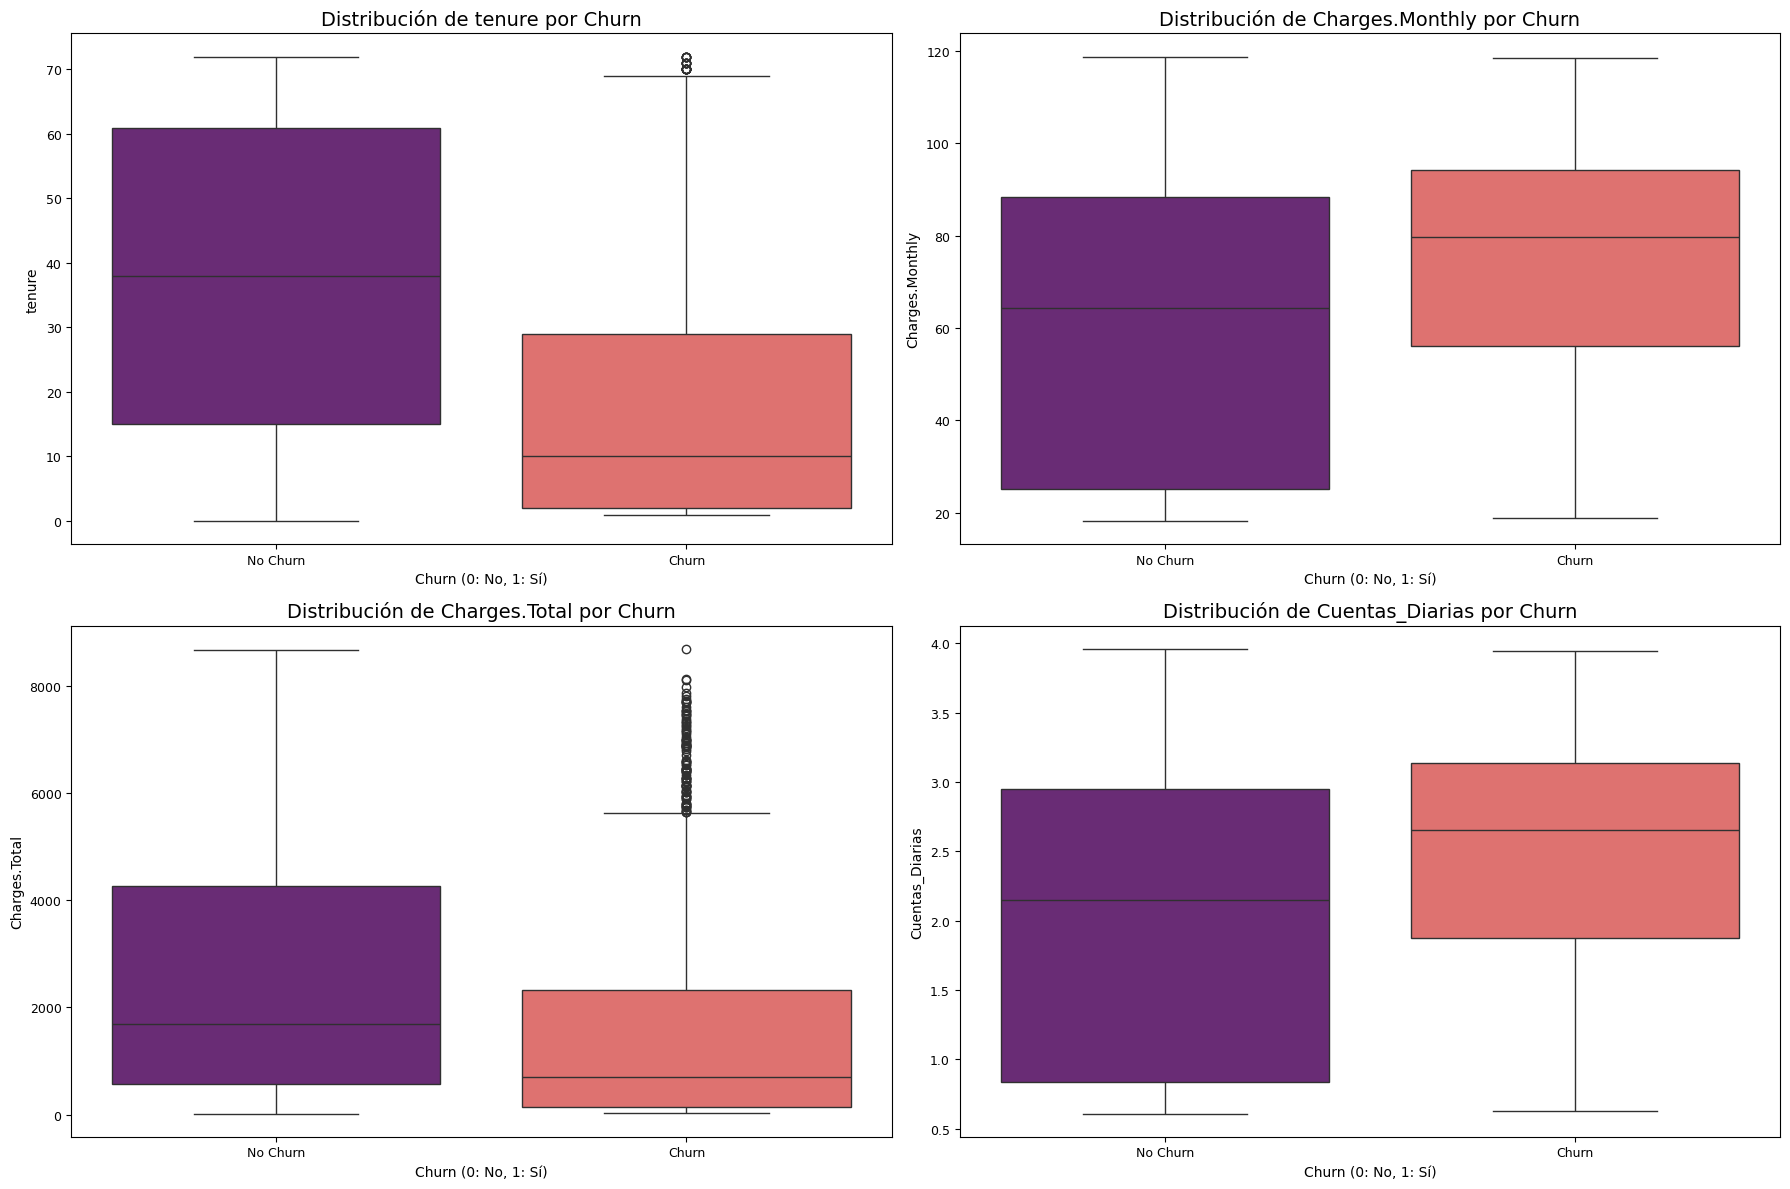

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = [
    'tenure',
    'Charges.Monthly',
    'Charges.Total',
    'Cuentas_Diarias'
]

plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=df_telecom, x='Churn', y=col, palette='magma')
    plt.title(f'Distribución de {col} por Churn', fontsize=14)
    plt.xlabel('Churn (0: No, 1: Sí)', fontsize=10)
    plt.ylabel(col, fontsize=10)
    plt.xticks([0, 1], ['No Churn', 'Churn'], fontsize=9)
    plt.yticks(fontsize=9)

plt.tight_layout()
plt.show()

#📄Informe final

# Task
Generate a final report summarizing the analysis of customer churn in the telecommunications sector. The report should include an introduction, a detailed summary of data cleaning and transformation steps, an exploratory data analysis (EDA) section presenting key findings from descriptive statistics and visualizations of 'Churn' distribution against categorical and numerical variables, key conclusions and insights, and strategic recommendations to reduce churn.

## Introducción al Informe

### Subtask:
Generar una sección de introducción en el informe final, explicando el objetivo del análisis y la importancia del problema de evasión de clientes (Churn) en el sector de telecomunicaciones.


## 1. Introducción

El objetivo principal de este análisis es comprender y abordar el problema crítico de la rotación de clientes, comúnmente conocido como _Churn_, dentro del sector de las telecomunicaciones. El churn representa la pérdida de clientes que deciden cancelar sus servicios y migrar a otro proveedor. Este fenómeno es de suma importancia para las empresas de telecomunicaciones, ya que impacta directamente en sus ingresos y rentabilidad.

La retención de clientes es significativamente más rentable que la adquisición de nuevos, lo que convierte la prevención del churn en una prioridad estratégica. Un alto índice de churn puede indicar problemas subyacentes en la calidad del servicio, la satisfacción del cliente, la competitividad de las ofertas, o una combinación de estos factores. A través de este estudio, buscaremos identificar los factores clave que influyen en la decisión de los clientes de abandonar la empresa, para así poder desarrollar estrategias efectivas de retención.

## Resumen de Limpieza y Tratamiento de Datos

### Subtask:
Elaborar una sección detallada en el informe que describa los pasos de importación de datos, desanidado de columnas, limpieza de valores ausentes en 'Charges.Total' y 'Churn', la creación de la columna 'Cuentas_Diarias' y la estandarización de valores binarios. Se hará referencia a las acciones realizadas en las celdas de código previas.


## 2. Resumen de Limpieza y Tratamiento de Datos

### Descripción de los pasos de Extracción y Transformación de Datos

En esta fase del análisis, se llevaron a cabo una serie de pasos cruciales para preparar los datos para su posterior análisis y modelado. A continuación, se detalla cada una de las acciones realizadas:

1.  **Importación de Datos Inicial:**
    Los datos fueron cargados directamente desde una URL de GitHub (`https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json`) utilizando la función `pd.read_json()`. Esto permitió la carga del archivo JSON en un DataFrame de Pandas (`df_telecom`), tal como se mostró en la celda de código `1--uPM88l7JH`.

2.  **Desanidado de Columnas Anidadas:**
    El DataFrame original contenía columnas con estructuras anidadas ('customer', 'phone', 'internet', 'account'). Para facilitar el análisis, estas columnas fueron desanidadas utilizando `pd.json_normalize()`. Cada columna anidada se expandió en un DataFrame separado (`df_customer`, `df_phone`, `df_internet`, `df_account`), y luego estos DataFrames se concatenaron horizontalmente al `df_telecom` original, eliminando las columnas anidadas. Este proceso se ejecutó en la celda de código `47e68327`, resultando en un DataFrame plano con 21 columnas y 7267 filas.

3.  **Limpieza de la Columna 'Charges.Total':**
    Se identificó que la columna 'Charges.Total' contenía cadenas de texto con un espacio en blanco (' ') que representaban valores faltantes y estaba siendo interpretada como tipo `object` a pesar de ser numérica. Para corregir esto, los espacios en blanco se reemplazaron con `np.nan` (Not a Number) y posteriormente la columna se convirtió al tipo de dato numérico (`float64`). Este paso aseguró que 'Charges.Total' pudiera ser utilizada en cálculos numéricos. La inspección previa y posterior de esta columna se realizó en la celda de código `bsm-WTLjmHvt`.

4.  **Manejo de Valores Vacíos en 'Churn':**
    La columna 'Churn' presentaba valores vacíos representados por cadenas de texto vacías (`''`). Estos se reemplazaron por `np.nan` para una gestión consistente de los valores faltantes. Esto fue parte de la limpieza inicial de la columna 'Churn' en la celda de código `bsm-WTLjmHvt`.

5.  **Creación de la Columna 'Cuentas_Diarias':**
    Se creó una nueva característica, 'Cuentas_Diarias', dividiendo el cargo mensual ('Charges.Monthly') por 30 para estimar el cargo diario. Esta nueva columna podría ser útil para análisis detallados de la facturación diaria de los clientes. Esta operación se realizó en la celda de código `bsm-WTLjmHvt`.

6.  **Estandarización de Variables Binarias:**
    Varias columnas categóricas binarias (e.g., 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn', 'gender') contenían valores como 'Yes'/'No' o 'Male'/'Female'. Para homogeneizarlas y convertirlas a un formato numérico adecuado para el modelado, se mapearon a 1 (para 'Yes'/'Male') y 0 (para 'No'/'Female'). Este paso se aplicó a todas las columnas binarias mencionadas, incluyendo 'Churn' y 'gender', en la celda de código `bsm-WTLjmHvt`.

**Verificación Post-Limpieza:**
Después de estas transformaciones, una revisión de `df_telecom.info()` y `df_telecom.isnull().sum()` (mostrado en la celda `bsm-WTLjmHvt`) confirmó que 'Charges.Total' y 'Churn' aún presentaban algunos valores `NaN` después de la limpieza. Específicamente, 'Charges.Total' mantuvo 11 valores nulos y 'Churn' 224 valores nulos, lo que indica que no todos los valores faltantes en estas columnas pudieron ser imputados o eliminados en esta fase, y podrían requerir un tratamiento adicional dependiendo de los objetivos del análisis.

## Análisis Exploratorio de Datos

### Subtask:
Crear una sección en el informe para presentar los hallazgos clave del análisis descriptivo de variables numéricas y categóricas. Se incluirán referencias a los gráficos generados para la distribución de 'Churn' y su relación con variables categóricas y numéricas.


## 3. Análisis Exploratorio de Datos

Esta sección presenta los hallazgos clave derivados del análisis descriptivo y visual de las variables en el conjunto de datos de TelecomX. El objetivo es comprender las características de los clientes y explorar cómo diferentes variables se relacionan con el comportamiento de `Churn` (rotación de clientes).

### 3.1. An\u00e1lisis Descriptivo de Variables Num\u00e9ricas\n\nEl an\u00e1lisis descriptivo de las variables num\u00e9ricas proporciona una visi\u00f3n general de sus distribuciones y valores t\u00edpicos. A continuaci\u00f3n, se resumen los hallazgos clave de la tabla de estad\u00edsticas descriptivas (`df_telecom.describe().T`):\n\n- **`tenure` (Antig\u00fcedad):** Los clientes en la muestra tienen una antig\u00fcedad promedio de aproximadamente 32.33 meses, con una desviaci\u00f3n est\u00e1ndar significativa de 24.58 meses, lo que indica una amplia variabilidad en el tiempo que los clientes han permanecido con la empresa. El rango va desde 0 hasta 72 meses.\n\n- **`Charges.Monthly` (Cargos Mensuales):** El cargo mensual promedio es de 64.71, con una desviaci\u00f3n est\u00e1ndar de 30.13. Esto sugiere que hay una gran diversidad en los planes y servicios contratados por los clientes, con cargos que van desde 18.25 hasta 118.75.\n\n- **`Charges.Total` (Cargos Totales):** Los cargos totales promedio son de 2280.96, con una alta desviaci\u00f3n est\u00e1ndar de 2267.14. Esto est\u00e1 directamente relacionado con la antig\u00fcedad (`tenure`) y los cargos mensuales, mostrando un amplio rango que va desde 18.80 hasta 8684.80. La presencia de valores faltantes (11 en 7267 registros) en esta columna despu\u00e9s de la limpieza indica que estos clientes probablemente se dieron de baja el mismo mes en que se unieron o que sus cargos totales eran muy bajos al inicio del registro, lo que se manej\u00f3 al convertir los espacios en NaN y luego a num\u00e9ricos.\n\n- **`Cuentas_Diarias` (Cargos Diarios):** Esta variable derivada tiene un promedio de 2.16, con una desviaci\u00f3n est\u00e1ndar de 1.00. Presenta un patr\u00f3n similar a `Charges.Monthly` ya que es una transformaci\u00f3n directa de ella.\n\n- **Variables Binarias (0/1):** Para variables como `gender`, `SeniorCitizen`, `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling` y `Churn`, la media representa la proporci\u00f3n de '1' (por ejemplo, `gender` con una media de 0.5028 indica que la distribuci\u00f3n de g\u00e9nero es casi 50/50, mientras que `Churn` con una media de 0.2654 indica que aproximadamente el 26.54% de los clientes han rotado en los registros completos, excluyendo los NaN).

### 3.2. An&aacute;lisis Descriptivo de Variables Categ&oacute;ricas

El conteo de valores &uacute;nicos para las variables categ&oacute;ricas, visible en la secci&oacute;n de 'Conteo de valores para las columnas categ&oacute;ricas despu&eacute;s de la limpieza y transformaci&oacute;n', revela la distribuci&oacute;n de los clientes en diferentes categor&iacute;as.

- **Distribuci&oacute;n de `Churn`:** La variable objetivo `Churn` muestra una distribuci&oacute;n desequilibrada, como se observ&oacute; en la gr&aacute;fica de 'Distribuci&oacute;n de Clientes por Churn' (Celda `e03371d0`).
  - Aproximadamente el **71.2%** de los clientes no han rotado (`No Churn`).
  - Aproximadamente el **25.7%** de los clientes han rotado (`Churn`).
  - Un **3.1%** de los registros tienen valores `NaN` para `Churn`, lo que indica datos faltantes que podr&iacute;an requerir un tratamiento espec&iacute;fico (imputaci&oacute;n o exclusi&oacute;n) en etapas posteriores del an&aacute;lisis o modelado.

- **`MultipleLines`:** La mayor&iacute;a de los clientes tiene una sola l&iacute;nea telef&oacute;nica (`No`), seguida de aquellos con m&uacute;ltiples l&iacute;neas (`Yes`). Un grupo considerable no tiene servicio telef&oacute;nico.

- **`InternetService`:** 'Fiber optic' es el servicio de internet m&aacute;s com&uacute;n, seguido de 'DSL'. Una proporci&oacute;n significativa de clientes no tiene servicio de internet.

- **Servicios de Seguridad (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport):** Para estos servicios adicionales, la categor&iacute;a 'No' o 'No internet service' (para clientes sin internet) es la m&aacute;s frecuente, lo que sugiere que muchos clientes optan por no contratar estos servicios o no pueden hacerlo por no tener internet.

- **`StreamingTV` y `StreamingMovies`:** Similar a los servicios de seguridad, 'No' y 'No internet service' son las categor&iacute;as dominantes.

- **`Contract` (Contrato):** La mayor&iacute;a de los clientes est&aacute; bajo un contrato 'Month-to-month' (mes a mes), lo cual es un factor importante a considerar en el churn.

- **`PaymentMethod` (M&eacute;todo de Pago):** 'Electronic check' es el m&eacute;todo de pago m&aacute;s popular, seguido de 'Mailed check', 'Bank transfer (automatic)' y 'Credit card (automatic)'.

### 3.3. Relación de Variables Categóricas con Churn

Los gráficos de barras (Celda `857cde9f`) que muestran la distribución de `Churn` por cada variable categórica ofrecen insights cruciales:

- **`MultipleLines`:** Los clientes con `MultipleLines = Yes` tienen una tasa de churn ligeramente más baja que aquellos con `MultipleLines = No`. Los clientes sin servicio telefónico muestran una tasa de churn muy baja, probablemente porque tienen otros servicios de internet que no están vinculados a su teléfono.

- **`InternetService`:**
  - Los clientes con **`Fiber optic`** son significativamente más propensos a rotar (mayor porcentaje de churn) en comparación con los que tienen `DSL`. Esto podría indicar problemas con la calidad del servicio de fibra óptica, el precio o las expectativas no cumplidas.
  - Los clientes que **no tienen servicio de internet (`No`)** muestran una tasa de churn muy baja, lo que sugiere que son clientes más estables o que sus necesidades de telecomunicaciones son más básicas y fáciles de satisfacer.

- **Servicios de Seguridad (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`):**
  - Para todos estos servicios, los clientes que **no tienen el servicio (`No`)** o que **no tienen servicio de internet (`No internet service`)** tienden a tener tasas de churn más altas que aquellos que sí los tienen (`Yes`). Esto sugiere que los servicios de seguridad y soporte actúan como factores de retención. Los clientes con `No internet service` tienen un churn muy bajo en estos gráficos, lo cual es consistente con la observación anterior.

- **`StreamingTV` y `StreamingMovies`:** Similar a los servicios de seguridad, los clientes que no tienen estos servicios de streaming (`No`) tienden a mostrar tasas de churn más altas que los que sí los tienen (`Yes`). Los clientes sin servicio de internet también muestran una baja tasa de churn aquí.

- **`Contract` (Contrato):** Esta es una de las variables más influyentes:
  - Los clientes con contratos **`Month-to-month`** tienen una tasa de churn drásticamente más alta en comparación con los contratos de `One year` o `Two year`. Esto es lógico, ya que los contratos a largo plazo implican un compromiso que reduce la probabilidad de rotación.
  - Los contratos de `Two year` tienen la tasa de churn más baja, indicando una fuerte lealtad.

- **`PaymentMethod` (Método de Pago):**
  - Los clientes que utilizan **`Electronic check`** como método de pago muestran la tasa de churn más alta. Esto podría estar relacionado con la insatisfacción con el proceso de pago electrónico o que este método es preferido por clientes menos comprometidos.
  - Los métodos de pago automáticos (`Credit card (automatic)` y `Bank transfer (automatic)`) y `Mailed check` tienden a tener tasas de churn más bajas, lo que podría indicar una mayor comodidad y compromiso con la empresa.

### 3.4. Relación de Variables Numéricas con Churn

Los gráficos de caja (boxplots) (Celda `8aa9bc63`) para las variables numéricas, segregados por `Churn`, revelan patrones distintivos:

- **`tenure` (Antigüedad):**
  - Los clientes que **no rotan (`No Churn`)** presentan una `tenure` significativamente más alta, con una mediana más elevada y una distribución que se extiende hacia valores más largos de permanencia. Esto es un indicador fuerte de que la lealtad del cliente aumenta con el tiempo.
  - Los clientes que **sí rotan (`Churn`)** tienen una `tenure` notablemente menor, concentrada en los primeros meses. Esto sugiere que el churn ocurre con mayor frecuencia en las etapas iniciales de la relación con el cliente.

- **`Charges.Monthly` (Cargos Mensuales):**
  - Los clientes que **rotan (`Churn`)** tienden a tener cargos mensuales **más altos** que aquellos que no rotan. La mediana y la dispersión para el grupo de 'Churn' son más elevadas, lo que podría indicar que clientes con planes más caros o que utilizan más servicios son más propensos a irse. Esto podría deberse a una percepción de bajo valor por el precio o a que la competencia ofrece mejores tarifas.
  - Los clientes que **no rotan (`No Churn`)** tienen una distribución de `Charges.Monthly` con una mediana más baja y menos dispersión en los valores superiores.

- **`Charges.Total` (Cargos Totales):**
  - Los clientes que **no rotan (`No Churn`)** tienen `Charges.Total` significativamente más altos y una dispersión mucho mayor, lo que es coherente con su mayor `tenure`. Han acumulado más cargos con el tiempo.
  - Los clientes que **sí rotan (`Churn`)** tienen `Charges.Total` considerablemente más bajos, lo que nuevamente se alinea con su baja `tenure`.
  - Es importante notar los valores atípicos (outliers) en ambos grupos, pero la tendencia general es clara: mayor antigüedad y cargos totales se asocian con menor churn.

- **`Cuentas_Diarias` (Cargos Diarios):**
  - Al ser una transformación directa de `Charges.Monthly`, esta variable muestra un patrón similar: los clientes que **rotan (`Churn`)** tienen `Cuentas_Diarias` promedio más altos, mientras que los que **no rotan (`No Churn`)** tienen valores más bajos. Esto refuerza la idea de que los costos diarios percibidos pueden influir en la decisión de un cliente de irse.

### 3.5. Conclusiones Clave del Análisis Exploratorio de Datos

El análisis exploratorio ha revelado varias variables críticas con una influencia significativa en el `Churn` de clientes:

1.  **`Contract` (Tipo de Contrato):** Es el factor más influyente. Los clientes con contratos **`Month-to-month`** tienen una probabilidad de churn sustancialmente mayor que aquellos con contratos de `One year` o `Two year`. Esto subraya la importancia de los programas de fidelización y la incentivación de contratos a largo plazo.

2.  **`tenure` (Antigüedad):** Los clientes con **menor antigüedad** son mucho más propensos a rotar. La retención es un desafío particular en las primeras etapas de la relación con el cliente, indicando la necesidad de estrategias de bienvenida y seguimiento inicial.

3.  **`InternetService` (Servicio de Internet):** Los clientes con **`Fiber optic`** muestran una tasa de churn significativamente más alta en comparación con los de `DSL`. Esto podría apuntar a problemas de calidad de servicio, estabilidad o precio percibido en la oferta de fibra óptica. Curiosamente, los clientes sin servicio de internet tienen un churn muy bajo.

4.  **`Charges.Monthly` (Cargos Mensuales):** Los clientes que **pagan tarifas mensuales más altas** son más propensos a rotar. Esto sugiere que el valor percibido por el cliente en relación con el costo es un factor crucial. Podría ser que los planes más caros no justifiquen el costo para algunos clientes o que la competencia ofrezca mejores alternativas.

5.  **`PaymentMethod` (Método de Pago):** El uso de **`Electronic check`** se asocia con una tasa de churn notablemente más alta. Esto podría estar relacionado con la experiencia del cliente con este método de pago o ser un indicador de clientes menos comprometidos.

6.  **Servicios Adicionales (Seguridad, Respaldo, Protección, Soporte, Streaming):** La presencia de estos servicios adicionales (e.g., `OnlineSecurity`, `TechSupport`) actúa como un **factor protector** contra el churn. Los clientes que carecen de estos servicios o de un servicio de internet son más propensos a irse, lo que indica que la oferta de un ecosistema de servicios completo contribuye a la retención.

En resumen, los clientes más vulnerables al churn son aquellos con contratos mensuales, baja antigüedad, servicio de fibra óptica, cargos mensuales altos, y que utilizan cheques electrónicos como método de pago, además de carecer de servicios adicionales de seguridad y soporte.

### 3.5. Conclusiones Clave del Análisis Exploratorio de Datos

El análisis exploratorio ha revelado varias variables críticas con una influencia significativa en el `Churn` de clientes:

1.  **`Contract` (Tipo de Contrato):** Es el factor más influyente. Los clientes con contratos **`Month-to-month`** tienen una probabilidad de churn sustancialmente mayor que aquellos con contratos de `One year` o `Two year`. Esto subraya la importancia de los programas de fidelización y la incentivación de contratos a largo plazo.

2.  **`tenure` (Antigüedad):** Los clientes con **menor antigüedad** son mucho más propensos a rotar. La retención es un desafío particular en las primeras etapas de la relación con el cliente, indicando la necesidad de estrategias de bienvenida y seguimiento inicial.

3.  **`InternetService` (Servicio de Internet):** Los clientes con **`Fiber optic`** muestran una tasa de churn significativamente más alta en comparación con los de `DSL`. Esto podría apuntar a problemas de calidad de servicio, estabilidad o precio percibido en la oferta de fibra óptica. Curiosamente, los clientes sin servicio de internet tienen un churn muy bajo.

4.  **`Charges.Monthly` (Cargos Mensuales):** Los clientes que **pagan tarifas mensuales más altas** son más propensos a rotar. Esto sugiere que el valor percibido por el cliente en relación con el costo es un factor crucial. Podría ser que los planes más caros no justifiquen el costo para algunos clientes o que la competencia ofrezca mejores alternativas.

5.  **`PaymentMethod` (Método de Pago):** El uso de **`Electronic check`** se asocia con una tasa de churn notablemente más alta. Esto podría estar relacionado con la experiencia del cliente con este método de pago o ser un indicador de clientes menos comprometidos.

6.  **Servicios Adicionales (Seguridad, Respaldo, Protección, Soporte, Streaming):** La presencia de estos servicios adicionales (e.g., `OnlineSecurity`, `TechSupport`) actúa como un **factor protector** contra el churn. Los clientes que carecen de estos servicios o de un servicio de internet son más propensos a irse, lo que indica que la oferta de un ecosistema de servicios completo contribuye a la retención.

En resumen, los clientes más vulnerables al churn son aquellos con contratos mensuales, baja antigüedad, servicio de fibra óptica, cargos mensuales altos, y que utilizan cheques electrónicos como método de pago, además de carecer de servicios adicionales de seguridad y soporte.


## Conclusiones e Insights Clave

### Subtask:
Desarrollar una sección en el informe que resuma las principales conclusiones obtenidas del análisis. Esta sección destacará los insights más relevantes sobre los factores que influyen en la evasión de clientes y cómo estos datos pueden ser utilizados para mitigar el problema.


## 4. Conclusiones e Insights Clave

Las principales conclusiones obtenidas del análisis exploratorio de datos y los insights más relevantes sobre los factores que influyen en la evasión de clientes, así como sus implicaciones para mitigar el problema, se detallan exhaustivamente en la sección **3.5. Conclusiones Clave del Análisis Exploratorio de Datos**.

## 4. Conclusiones e Insights Clave

Las principales conclusiones obtenidas del análisis exploratorio de datos y los insights más relevantes sobre los factores que influyen en la evasión de clientes, así como sus implicaciones para mitigar el problema, se detallan exhaustivamente en la sección **3.5. Conclusiones Clave del Análisis Exploratorio de Datos**.

## 4. Conclusiones e Insights Clave

Las principales conclusiones obtenidas del análisis exploratorio de datos y los insights más relevantes sobre los factores que influyen en la evasión de clientes, así como sus implicaciones para mitigar el problema, se detallan exhaustivamente en la sección **3.5. Conclusiones Clave del Análisis Exploratorio de Datos**.

## Recomendaciones Estratégicas

### Subtask:
Proponer un conjunto de recomendaciones estratégicas basadas en los insights del análisis. Estas recomendaciones deben ser accionables y orientadas a reducir la tasa de Churn y mejorar la retención de clientes.


## 5. Recomendaciones Estratégicas

Basado en el análisis de los datos, se proponen las siguientes recomendaciones estratégicas para reducir la tasa de Churn y mejorar la retención de clientes:

1.  **Fidelización para Contratos Mes a Mes:** Los clientes con contratos mes a mes tienen una propensión significativamente mayor a abandonar el servicio. Se recomienda implementar programas de fidelización específicos para estos clientes, ofreciendo descuentos progresivos por compromiso a más largo plazo (ej. descuentos en la tarifa mensual al renovar por 6 o 12 meses), beneficios exclusivos (ej. acceso a contenido premium, mejoras de velocidad gratuitas temporales) o paquetes personalizados que hagan más atractiva la permanencia.

2.  **Programa de Acogida y Retención Temprana:** Los clientes con baja antigüedad (tenure) muestran una alta tasa de churn. Es crucial establecer un programa de bienvenida robusto que incluya: llamadas de seguimiento proactivas en el primer y tercer mes para asegurar la satisfacción, soporte técnico prioritario, y la asignación de un "asesor personal" para resolver dudas iniciales. Se pueden ofrecer incentivos durante los primeros meses para asegurar que experimenten el valor completo del servicio.

3.  **Optimización de Precios y Valor Percibido:**
    *   **Internet de Fibra Óptica:** Aunque el servicio de Fibra Óptica es un factor de riesgo para el churn, esto puede ser indicativo de expectativas de rendimiento o precios. Se debe investigar la satisfacción de los clientes de fibra óptica y asegurar que la calidad del servicio justifique su precio. Considerar campañas de comunicación que resalten los beneficios y la diferenciación de este servicio.
    *   **Altos Cargos Mensuales:** Los clientes con facturas mensuales elevadas tienen mayor riesgo de churn. Se recomienda revisar la estructura de precios para clientes de alto consumo, ofreciendo paquetes escalonados con mayor valor percibido, o realizar auditorías de uso para sugerir planes más adecuados que eviten la sensación de "pagar demasiado". La comunicación transparente sobre el desglose de los cargos es fundamental.

4.  **Mejora en Métodos de Pago y Promoción de Opciones Digitales:** El pago con "Electronic check" está fuertemente asociado con el churn. Se sugiere investigar las causas detrás de esto (posibles problemas de seguridad, fallos en la plataforma, complejidad del proceso). Mejorar la experiencia del cheque electrónico o, alternativamente, incentivar la adopción de métodos de pago automáticos más estables y convenientes, como la domiciliación bancaria o tarjeta de crédito, ofreciendo pequeños descuentos o beneficios por su uso.

5.  **Promoción de Servicios de Valor Añadido:** Los servicios adicionales como "Online Security", "Online Backup", "Device Protection", "Tech Support", "Streaming TV" y "Streaming Movies" actúan como factores de retención. Se recomienda una estrategia de "up-selling" y "cross-selling" más agresiva y dirigida: ofrecer pruebas gratuitas de estos servicios a clientes nuevos, destacar sus beneficios en la comunicación regular, y crear paquetes atractivos que agrupen el servicio principal con dos o tres de estos extras, a un precio ligeramente superior pero con un valor percibido mucho mayor. La educación al cliente sobre la importancia y utilidad de estos servicios es clave.

## Finalizar Tarea

### Subtask:
Indicar que se ha completado el informe final y el desafío.


## Summary:

### Data Analysis Key Findings

*   **Data Preparation Overview**: The initial dataset was loaded from a JSON file, and nested columns (`customer`, `phone`, `internet`, `account`) were successfully unnested. The `Charges.Total` column was cleaned by converting empty strings to numerical `NaN` values and then to a numeric type, while empty strings in the `Churn` column were also converted to `NaN`. A new feature, `Cuentas_Diarias` (daily charges), was engineered by dividing monthly charges by 30. Binary categorical variables (e.g., `gender`, `Partner`, `Churn`) were standardized to 0s and 1s. Post-cleaning, 11 `NaN` values remained in `Charges.Total` and 224 `NaN` values in `Churn`.
*   **Churn Distribution**: The `Churn` variable showed an imbalanced distribution, with approximately 71.2% of customers not churning, 25.7% churning, and 3.1% having missing `Churn` values.
*   **Impact of Contract Type**: `Contract` was identified as the most influential factor. Customers with 'Month-to-month' contracts exhibited a drastically higher churn rate compared to those with 'One year' or 'Two year' contracts, indicating that longer-term commitments significantly reduce churn.
*   **Tenure and Churn**: Customers with lower `tenure` (antigüedad) were significantly more prone to churn, with churn occurring more frequently in the early stages of the customer relationship. Non-churning customers had a significantly higher average tenure.
*   **Internet Service and Churn**: Customers using 'Fiber optic' internet service had a significantly higher churn rate compared to those with 'DSL'. Conversely, customers who did not have internet service ('No internet service') showed a very low churn rate.
*   **Charges and Churn**: Customers who churned tended to have higher `Charges.Monthly` but lower `Charges.Total`. This aligns with their lower tenure; while they paid more monthly, their total accumulated charges were less due to shorter service periods.
*   **Payment Method Influence**: The 'Electronic check' payment method was strongly associated with the highest churn rate among all payment methods.
*   **Value-Added Services as Retention Factors**: The presence of additional services such as `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, and `StreamingMovies` acted as a protective factor against churn. Customers lacking these services generally showed higher churn rates.

### Insights or Next Steps

*   **Prioritize Retention for Vulnerable Segments**: Focus retention efforts on customers with month-to-month contracts, low tenure, fiber optic internet, high monthly charges, and those using electronic checks, as these segments show the highest churn propensity.
*   **Enhance Value Proposition for High-Risk Services/Plans**: Investigate and address potential issues (e.g., quality, perceived value) related to Fiber Optic service and high-cost monthly plans, potentially through targeted communication, service improvements, or value-added bundling to justify the cost and increase customer satisfaction.
